<a href="https://colab.research.google.com/github/laboratoriodecodigos/Colab-Python/blob/main/Teeth_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("humansintheloop/teeth-segmentation-on-dental-x-ray-images")

print("Path to dataset files:", path)

100%|██████████| 4.14G/4.14G [00:35<00:00, 124MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/humansintheloop/teeth-segmentation-on-dental-x-ray-images/versions/1


In [2]:
!pip install -q ultralytics onnx onnxruntime albumentations

import ultralytics
ultralytics.checks()
print(f'Ultralytics: {ultralytics.__version__}')

Ultralytics 8.4.157 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 52.8/112.6 GB disk)
Ultralytics: 8.4.157


In [6]:
import json, shutil, random, cv2, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm
from collections import defaultdict
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [3]:
import os
print(os.listdir(path))

['Teeth Segmentation PNG', 'Teeth Segmentation JSON']


In [8]:
from pathlib import Path
# ── Paths ────────────────────────────────────────────────────────────────────
DATASET_ROOT = Path(path)
JSON_ROOT    = DATASET_ROOT / 'Teeth Segmentation JSON' / 'd2'
ANN_DIR      = JSON_ROOT / 'ann'
IMG_DIR      = JSON_ROOT / 'img'
WORK_DIR     = Path('/kaggle/working')
YOLO_DIR     = WORK_DIR / 'yolo_dataset'

print('Images     :', len(list(IMG_DIR.glob('*'))))
print('Annotations:', len(list(ANN_DIR.glob('*.json'))))

Images     : 598
Annotations: 598


In [9]:
FDI_NAMES = {
    '1' : 'UR3 - Upper Right Lateral Incisor',
    '2' : 'UR2 - Upper Right Central Incisor',
    '3' : 'UR1 - Upper Right Central Incisor',
    '4' : 'UR4 - Upper Right First Premolar',
    '5' : 'UR5 - Upper Right Second Premolar',
    '6' : 'UR6 - Upper Right First Molar',
    '7' : 'UR7 - Upper Right Second Molar',
    '8' : 'UR8 - Upper Right Wisdom Tooth',
    '9' : 'UL1 - Upper Left Central Incisor',
    '10': 'UL2 - Upper Left Lateral Incisor',
    '11': 'UL3 - Upper Left Canine',
    '12': 'UL4 - Upper Left First Premolar',
    '13': 'UL5 - Upper Left Second Premolar',
    '14': 'UL6 - Upper Left First Molar',
    '15': 'UL7 - Upper Left Second Molar',
    '16': 'UL8 - Upper Left Wisdom Tooth',
    '17': 'LL8 - Lower Left Wisdom Tooth',
    '18': 'LL7 - Lower Left Second Molar',
    '19': 'LL6 - Lower Left First Molar',
    '20': 'LL5 - Lower Left Second Premolar',
    '21': 'LL4 - Lower Left First Premolar',
    '22': 'LL3 - Lower Left Canine',
    '23': 'LL2 - Lower Left Lateral Incisor',
    '24': 'LL1 - Lower Left Central Incisor',
    '25': 'LR1 - Lower Right Central Incisor',
    '26': 'LR2 - Lower Right Lateral Incisor',
    '27': 'LR3 - Lower Right Canine',
    '28': 'LR4 - Lower Right First Premolar',
    '29': 'LR5 - Lower Right Second Premolar',
    '30': 'LR6 - Lower Right First Molar',
    '31': 'LR7 - Lower Right Second Molar',
    '32': 'LR8 - Lower Right Wisdom Tooth',
}

In [10]:
# Sorted numerically → consistent YOLO class IDs 0–31
CLASSES   = [str(i) for i in range(1, 33)]  # ['1','2',...,'32']
CLASS2ID  = {c: i for i, c in enumerate(CLASSES)}
ID2NAME   = {i: FDI_NAMES[c] for c, i in CLASS2ID.items()}
NUM_CLASSES = len(CLASSES)  # 32

In [11]:
# Known instance counts from the analysis
INSTANCE_COUNTS = {
    '1':332,'2':487,'3':448,'4':448,'5':452,'6':535,'7':508,'8':518,
    '9':519,'10':511,'11':536,'12':465,'13':442,'14':446,'15':503,'16':321,
    '17':323,'18':420,'19':361,'20':515,'21':548,'22':588,'23':584,'24':575,
    '25':581,'26':582,'27':590,'28':559,'29':518,'30':358,'31':428,'32':317,
}

In [12]:
print(f'Total classes  : {NUM_CLASSES}')
print(f'Total instances: {sum(INSTANCE_COUNTS.values())}')
print(f'Min instances  : {min(INSTANCE_COUNTS.values())} (tooth {min(INSTANCE_COUNTS, key=INSTANCE_COUNTS.get)})')
print(f'Max instances  : {max(INSTANCE_COUNTS.values())} (tooth {max(INSTANCE_COUNTS, key=INSTANCE_COUNTS.get)})')
print(f'Imbalance ratio: {max(INSTANCE_COUNTS.values())/min(INSTANCE_COUNTS.values()):.2f}x')

Total classes  : 32
Total instances: 15318
Min instances  : 317 (tooth 32)
Max instances  : 590 (tooth 27)
Imbalance ratio: 1.86x


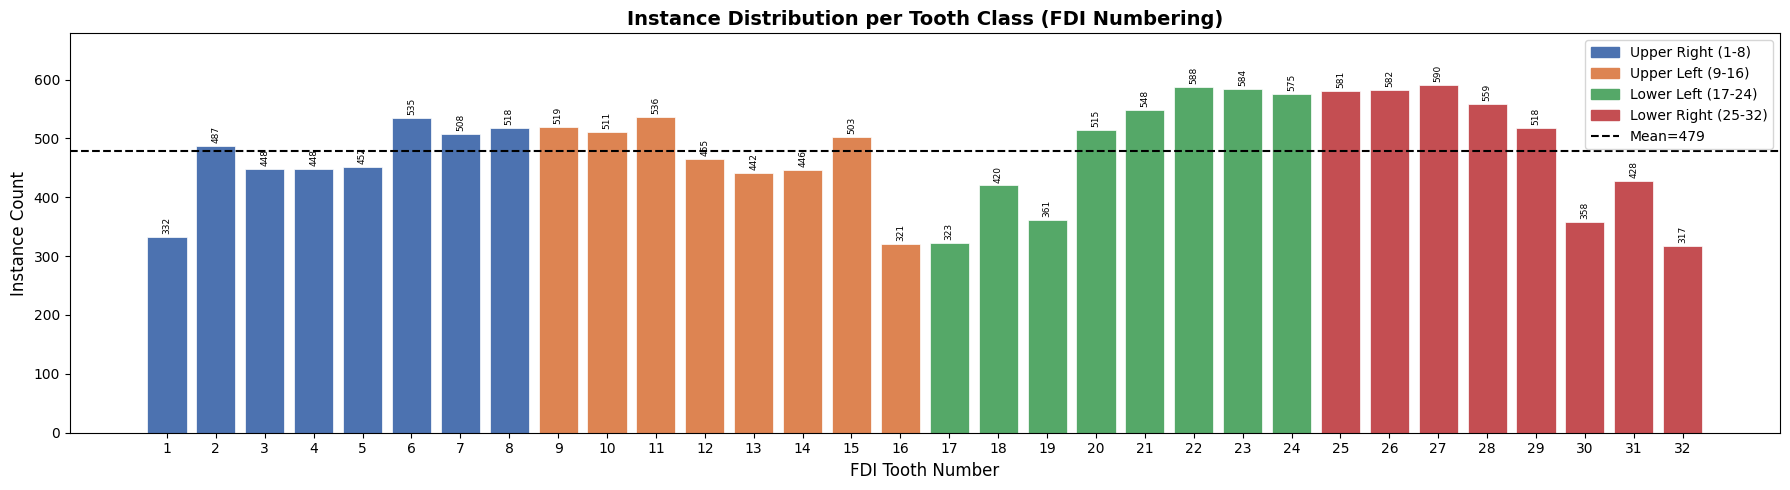


⚠️  Wisdom teeth (often missing/unerupted) are underrepresented:
   Tooth  1: 332 instances  (69% of mean)
   Tooth  8: 518 instances  (108% of mean)
   Tooth 16: 321 instances  (67% of mean)
   Tooth 17: 323 instances  (67% of mean)
   Tooth 32: 317 instances  (66% of mean)


In [15]:
import matplotlib.patches as mpatches
# ── Visualise class distribution ─────────────────────────────────────────────
counts = [INSTANCE_COUNTS[c] for c in CLASSES]
mean_c = np.mean(counts)

# Colour by quadrant
quadrant_colors = (
    ['#4C72B0']*8 +   # Upper Right (1-8)
    ['#DD8452']*8 +   # Upper Left  (9-16)
    ['#55A868']*8 +   # Lower Left  (17-24)
    ['#C44E52']*8     # Lower Right (25-32)
)

fig, ax = plt.subplots(figsize=(18, 5))
bars = ax.bar(CLASSES, counts, color=quadrant_colors, edgecolor='white', linewidth=0.5)
ax.axhline(mean_c, color='black', linestyle='--', linewidth=1.5, label=f'Mean = {mean_c:.0f}')
ax.set_xlabel('FDI Tooth Number', fontsize=12)
ax.set_ylabel('Instance Count', fontsize=12)
ax.set_title('Instance Distribution per Tooth Class (FDI Numbering)', fontsize=14, fontweight='bold')
legend_patches = [
    mpatches.Patch(color='#4C72B0', label='Upper Right (1-8)'),
    mpatches.Patch(color='#DD8452', label='Upper Left (9-16)'),
    mpatches.Patch(color='#55A868', label='Lower Left (17-24)'),
    mpatches.Patch(color='#C44E52', label='Lower Right (25-32)'),
]
ax.legend(handles=legend_patches + [plt.Line2D([0],[0], color='black', linestyle='--', label=f'Mean={mean_c:.0f}')])
ax.set_ylim(0, max(counts)*1.15)
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5, str(cnt),
            ha='center', va='bottom', fontsize=6.5, rotation=90)
plt.tight_layout()
WORK_DIR.mkdir(parents=True, exist_ok=True) # Create the directory if it doesn't exist
plt.savefig(WORK_DIR / 'class_distribution.png', dpi=130)
plt.show()

# Wisdom teeth are underrepresented
wisdom = {'1':332, '8':518, '16':321, '17':323, '32':317}
print('\n⚠️  Wisdom teeth (often missing/unerupted) are underrepresented:')
for t, c in wisdom.items():
    print(f'   Tooth {t:>2}: {c} instances  ({c/mean_c*100:.0f}% of mean)')

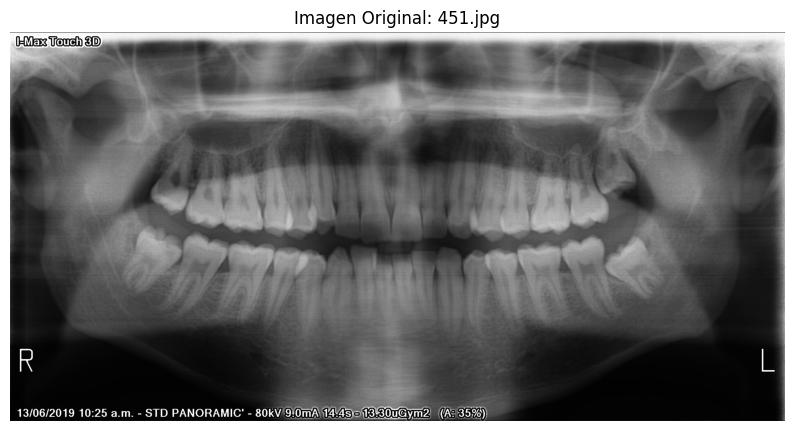

In [40]:
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

# La ruta al directorio de imágenes ya está definida como IMG_DIR
# Si '451.jpg' es una imagen de prueba, podríamos buscarla en test_images o directamente en IMG_DIR.
# Asumiendo que '451.jpg' se encuentra en el directorio original de imágenes

# Construir la ruta a la imagen específica
image_name = '451.jpg'

# Buscar en el directorio de imágenes original o en el de test si ya se ha copiado
# Si la imagen 451.jpg está en el conjunto de prueba, podemos usar la ruta de `test_images`
# De lo contrario, la buscaremos en el directorio original `IMG_DIR`

image_path = None
for path_obj in test_images:
    if path_obj.name == image_name:
        image_path = path_obj
        break

if image_path is None:
    # Si no se encontró en test_images, buscar en el directorio original
    image_path = IMG_DIR / image_name

if image_path.exists():
    # Cargar la imagen
    img = Image.open(image_path).convert('RGB')

    # Mostrar la imagen
    plt.figure(figsize=(10, 8))
    plt.imshow(img)
    plt.title(f'Imagen Original: {image_name}')
    plt.axis('off')
    plt.show()
else:
    print(f"Error: La imagen '{image_name}' no se encontró en las rutas esperadas ({image_path}).")


In [16]:
# ── Compute class weights for loss balancing ──────────────────────────────────
# Inverse-frequency weighting, clipped to [0.5, 2.0] to avoid extreme values
total_instances = sum(counts)
class_weights = []
for c in CLASSES:
    w = total_instances / (NUM_CLASSES * INSTANCE_COUNTS[c])
    w = float(np.clip(w, 0.5, 2.0))
    class_weights.append(w)

print('Class weights (inverse-frequency, clipped [0.5, 2.0]):')
for i, (c, w) in enumerate(zip(CLASSES, class_weights)):
    short = FDI_NAMES[c][:35]
    bar   = '█' * int(w * 10)
    print(f'  [{i:2d}] Tooth {c:>2} | {short:<35} | w={w:.3f}  {bar}')

Class weights (inverse-frequency, clipped [0.5, 2.0]):
  [ 0] Tooth  1 | UR3 - Upper Right Lateral Incisor   | w=1.442  ██████████████
  [ 1] Tooth  2 | UR2 - Upper Right Central Incisor   | w=0.983  █████████
  [ 2] Tooth  3 | UR1 - Upper Right Central Incisor   | w=1.068  ██████████
  [ 3] Tooth  4 | UR4 - Upper Right First Premolar    | w=1.068  ██████████
  [ 4] Tooth  5 | UR5 - Upper Right Second Premolar   | w=1.059  ██████████
  [ 5] Tooth  6 | UR6 - Upper Right First Molar       | w=0.895  ████████
  [ 6] Tooth  7 | UR7 - Upper Right Second Molar      | w=0.942  █████████
  [ 7] Tooth  8 | UR8 - Upper Right Wisdom Tooth      | w=0.924  █████████
  [ 8] Tooth  9 | UL1 - Upper Left Central Incisor    | w=0.922  █████████
  [ 9] Tooth 10 | UL2 - Upper Left Lateral Incisor    | w=0.937  █████████
  [10] Tooth 11 | UL3 - Upper Left Canine             | w=0.893  ████████
  [11] Tooth 12 | UL4 - Upper Left First Premolar     | w=1.029  ██████████
  [12] Tooth 13 | UL5 - Upper Left Sec

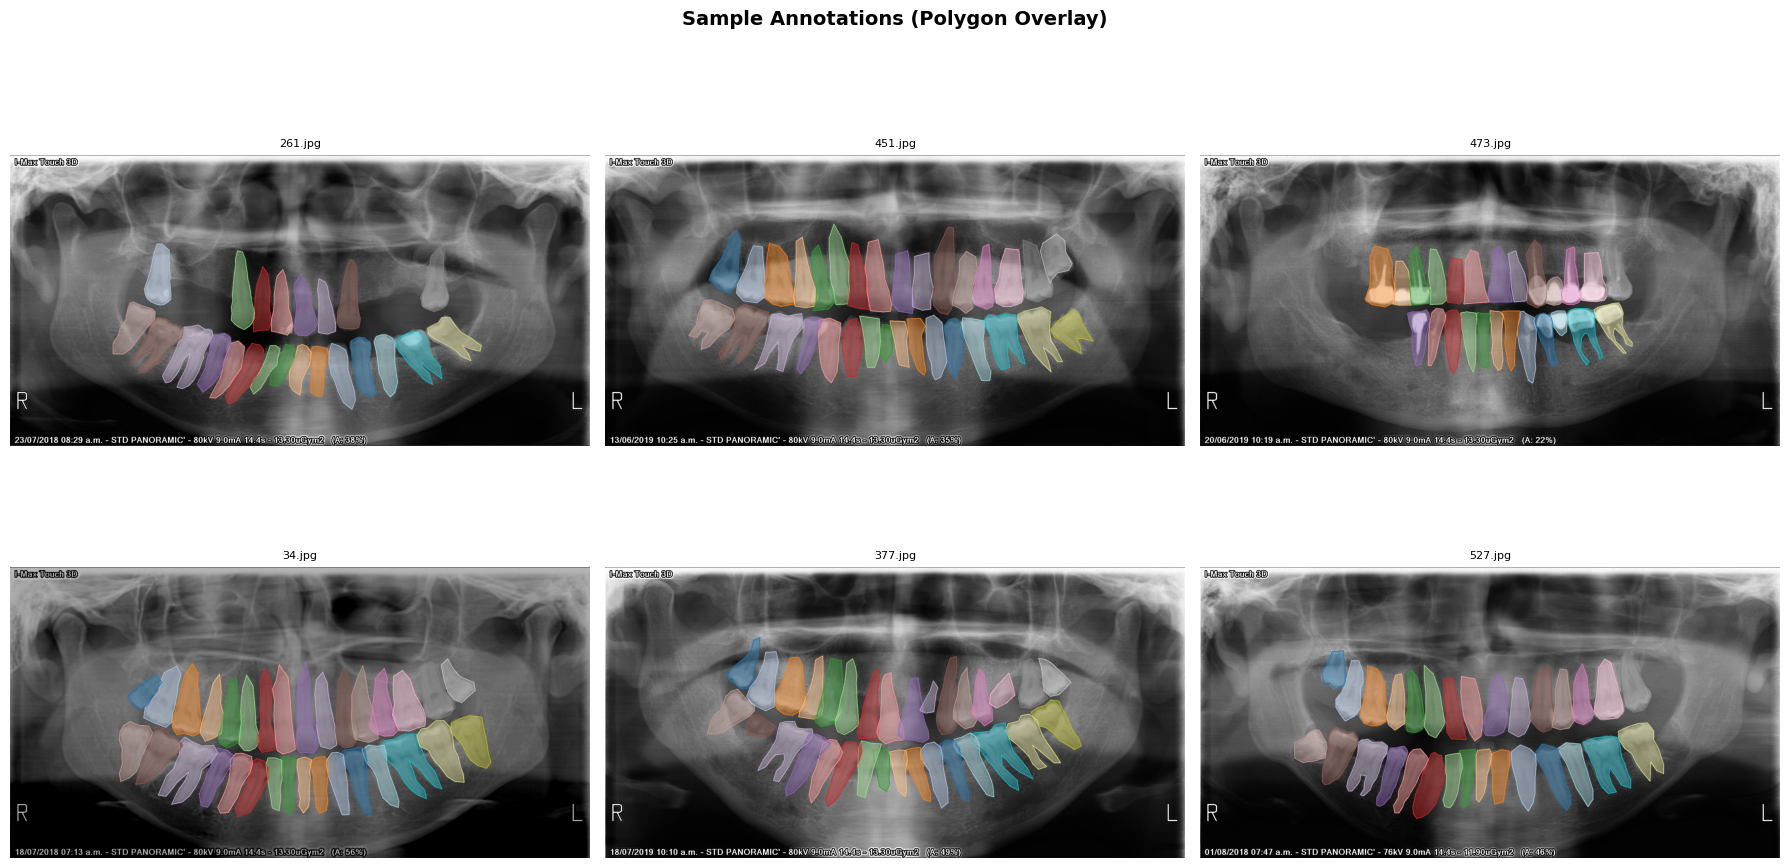

In [20]:
 #─── Visualise a few raw images with polygon overlays ────────────────────────
COLORS = plt.cm.tab20.colors

def draw_supervisely_ann(img_path, ann_path, class_map):
    img = np.array(Image.open(img_path).convert('RGB'))
    with open(ann_path) as f:
        ann = json.load(f)
    overlay = img.copy()
    for obj in ann.get('objects', []):
        cls  = obj.get('classTitle', 'unknown')
        cidx = class_map.get(cls, 0)
        color = tuple(int(c*255) for c in COLORS[cidx % len(COLORS)][:3])
        geo  = obj.get('labelsMap') or obj.get('bitmap')
        pts  = obj.get('points', {}).get('exterior', [])
        if pts:
            poly = np.array(pts, dtype=np.int32)
            cv2.fillPoly(overlay, [poly], color)
            cv2.polylines(img, [poly], True, color, 2)
    blended = cv2.addWeighted(img, 0.6, overlay, 0.4, 0)
    return blended

# Build a quick class→index map for visualisation
vis_class_map = CLASS2ID

ann_files = list(ANN_DIR.glob('*.json'))
sample_anns = random.sample(ann_files, min(6, len(ann_files)))
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, af in zip(axes.flat, sample_anns):
    stem = af.stem   # annotation filename stem (may have .jpg/.png appended)
    # Try finding the matching image
    img_candidates = list(IMG_DIR.glob(f'{stem}*'))
    if not img_candidates:
        ax.axis('off'); continue
    vis = draw_supervisely_ann(img_candidates[0], af, vis_class_map)
    ax.imshow(vis)
    ax.set_title(af.stem[:40], fontsize=8)
    ax.axis('off')
plt.suptitle('Sample Annotations (Polygon Overlay)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(WORK_DIR / 'sample_annotations.png', dpi=120)
plt.show()

In [21]:
ann_files = sorted(ANN_DIR.glob('*.json'))

def supervisely_to_yolo_seg(ann_path, img_dir, class2id):
    """
    Convert Supervisely JSON → YOLO seg label lines.
    Returns (img_path, yolo_lines) or (None, None).
    """
    with open(ann_path) as f:
        ann = json.load(f)

    stem = ann_path.stem
    candidates = list(img_dir.glob(f'{stem}*'))
    if not candidates:
        return None, None
    img_path = candidates[0]

    H = ann['size']['height']
    W = ann['size']['width']

    yolo_lines = []
    for obj in ann.get('objects', []):
        cls = str(obj.get('classTitle', '')).strip()
        if cls not in class2id:
            continue
        cid = class2id[cls]

        exterior = obj.get('points', {}).get('exterior', [])
        if len(exterior) < 3:
            continue

        # Remove duplicate closing point if present
        if exterior[0] == exterior[-1]:
            exterior = exterior[:-1]

        # Normalise + clamp to [0, 1]
        coords = []
        for x, y in exterior:
            coords.append(round(float(np.clip(x / W, 0.0, 1.0)), 6))
            coords.append(round(float(np.clip(y / H, 0.0, 1.0)), 6))

        yolo_lines.append(f"{cid} " + ' '.join(map(str, coords)))

    return img_path, yolo_lines


# ── Run conversion ────────────────────────────────────────────────────────────
valid_samples = []   # list of (img_path, label_lines, class_ids_present)
skipped = 0

for af in tqdm(ann_files, desc='Converting'):
    img_path, lines = supervisely_to_yolo_seg(af, IMG_DIR, CLASS2ID)
    if img_path is None or not lines:
        skipped += 1
        continue
    class_ids = list({int(l.split()[0]) for l in lines})
    valid_samples.append((img_path, lines, class_ids))

print(f'Valid samples : {len(valid_samples)}')
print(f'Skipped       : {skipped}')

Converting:   0%|          | 0/598 [00:00<?, ?it/s]

Valid samples : 595
Skipped       : 3


In [22]:
# ── Improved stratify (robust & safe) ────────────────────────────────────────
# Use a better proxy than max(cids) لتجنب bias
strat_labels = [sum(cids) % 8 for _, _, cids in valid_samples]

# Optional safety check (مهم جدًا)
from collections import Counter
counts = Counter(strat_labels)
print("Strat distribution:", counts)

# لو فيه class أقل من 2 → شيل stratify
use_stratify = all(v >= 2 for v in counts.values())

indices = list(range(len(valid_samples)))

train_idx, testval_idx = train_test_split(
    indices,
    test_size=0.15,
    random_state=SEED,
    stratify=strat_labels if use_stratify else None
)

# Second split
strat_testval = [strat_labels[i] for i in testval_idx] if use_stratify else None

val_idx, test_idx = train_test_split(
    testval_idx,
    test_size=0.33,
    random_state=SEED,
    stratify=strat_testval if use_stratify else None
)

print(f'Train : {len(train_idx)}  ({len(train_idx)/len(valid_samples)*100:.1f}%)')
print(f'Val   : {len(val_idx)}    ({len(val_idx)/len(valid_samples)*100:.1f}%)')
print(f'Test  : {len(test_idx)}   ({len(test_idx)/len(valid_samples)*100:.1f}%)')

# ── Build directory structure ────────────────────────────────────────────────
for split in ('train', 'val', 'test'):
    (YOLO_DIR / 'images' / split).mkdir(parents=True, exist_ok=True)
    (YOLO_DIR / 'labels' / split).mkdir(parents=True, exist_ok=True)

def write_split(idxs, split_name):
    for i in tqdm(idxs, desc=f'Writing {split_name}'):
        img_path, lines, _ = valid_samples[i]

        shutil.copy2(img_path, YOLO_DIR / 'images' / split_name / img_path.name)

        lbl_path = YOLO_DIR / 'labels' / split_name / (img_path.stem + '.txt')
        lbl_path.write_text('\n'.join(lines))

write_split(train_idx, 'train')
write_split(val_idx,   'val')
write_split(test_idx,  'test')

print('\n✅ Dataset written!')

Strat distribution: Counter({0: 164, 1: 85, 2: 68, 3: 61, 4: 60, 5: 56, 6: 53, 7: 48})
Train : 505  (84.9%)
Val   : 60    (10.1%)
Test  : 30   (5.0%)


Writing train:   0%|          | 0/505 [00:00<?, ?it/s]

Writing val:   0%|          | 0/60 [00:00<?, ?it/s]

Writing test:   0%|          | 0/30 [00:00<?, ?it/s]


✅ Dataset written!


In [23]:
# ── Dataset YAML ──────────────────────────────────────────────────────────────
yaml_lines = [
    f'path: {YOLO_DIR}',
    f'train: images/train',
    f'val:   images/val',
    f'test:  images/test',
    f'',
    f'nc: {NUM_CLASSES}',
    f'names:',
]
# Use short FDI codes as names (cleaner in plots)
for i, c in enumerate(CLASSES):
    short = FDI_NAMES[c].split(' - ')[0]  # e.g. 'UR3'
    yaml_lines.append(f'  {i}: "{short}_T{c}"')

yaml_content = '\n'.join(yaml_lines)
yaml_path = YOLO_DIR / 'teeth_seg.yaml'
yaml_path.write_text(yaml_content)
print(yaml_content)

path: /kaggle/working/yolo_dataset
train: images/train
val:   images/val
test:  images/test

nc: 32
names:
  0: "UR3_T1"
  1: "UR2_T2"
  2: "UR1_T3"
  3: "UR4_T4"
  4: "UR5_T5"
  5: "UR6_T6"
  6: "UR7_T7"
  7: "UR8_T8"
  8: "UL1_T9"
  9: "UL2_T10"
  10: "UL3_T11"
  11: "UL4_T12"
  12: "UL5_T13"
  13: "UL6_T14"
  14: "UL7_T15"
  15: "UL8_T16"
  16: "LL8_T17"
  17: "LL7_T18"
  18: "LL6_T19"
  19: "LL5_T20"
  20: "LL4_T21"
  21: "LL3_T22"
  22: "LL2_T23"
  23: "LL1_T24"
  24: "LR1_T25"
  25: "LR2_T26"
  26: "LR3_T27"
  27: "LR4_T28"
  28: "LR5_T29"
  29: "LR6_T30"
  30: "LR7_T31"
  31: "LR8_T32"


In [26]:
from ultralytics import YOLO

model = YOLO('yolov8m-seg.pt')

results = model.train(
    data=str(yaml_path),
    epochs=10,
    imgsz=640,

    batch=6,
    device=0,

    amp=True,
    workers=2,

    # masks
    mask_ratio=2,

    # optimizer
    optimizer='AdamW',
    lr0=1e-3,
    cos_lr=True,

    project=str(WORK_DIR / 'runs'),
    name='teeth_safe_run'
)

Ultralytics 8.4.157 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=6, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/yolo_dataset/teeth_seg.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=2, max_det=300, mixup=0.0, mode=train, model=yolov8m-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=teeth_safe_run-2, nbs=64, nms

In [27]:
from ultralytics import YOLO
from pathlib import Path

# define path explicitly
best_weights = Path("/kaggle/working/runs/teeth_safe_run/weights/best.pt")

# load model
best_model = YOLO(str(best_weights))

results_dict = {}

for split_name in ['val', 'test']:
    print(f'\n=== {split_name.upper()} SET ===')

    try:
        metrics = best_model.val(
            data=str(yaml_path),
            split=split_name,
            imgsz=640,
            device=0,
            plots=True,
            verbose=False
        )

        results_dict[split_name] = metrics

        print(f'  Box  mAP@50     : {metrics.box.map50:.4f}')
        print(f'  Box  mAP@50-95  : {metrics.box.map:.4f}')
        print(f'  Mask mAP@50     : {metrics.seg.map50:.4f}')
        print(f'  Mask mAP@50-95  : {metrics.seg.map:.4f}')

    except Exception as e:
        print(f'❌ Failed on {split_name}: {e}')

# Access later if needed
val_metrics  = results_dict.get('val', None)
test_metrics = results_dict.get('test', None)


=== VAL SET ===
Ultralytics 8.4.157 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8m-seg summary (fused): 105 layers, 27,240,912 parameters, 0 gradients, 104.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3477.6±735.4 MB/s, size: 772.7 KB)
val: Scanning /kaggle/working/yolo_dataset/labels/val.cache... 60 images, 0 backgrounds, 1 corrupt: 100% ━━━━━━━━━━━━ 60/60 11.4Mit/s 0.0s
val: /kaggle/working/yolo_dataset/images/val/32.jpg: ignoring corrupt image/label: labels mix segment and detection rows
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 2.2s/it 8.8s
                   all         59       1553      0.855      0.867      0.932      0.631      0.856      0.869      0.933      0.563
Speed: 11.7ms preprocess, 33.2ms inference, 0.0ms loss, 17.3ms postprocess per image
Results saved to /content/runs/segment/val
  Box  mAP@50     : 0.9325
  Box  

In [28]:
try:
    import pandas as pd

    per_class_map50 = val_metrics.seg.maps50

    cls_names_short = [
        FDI_NAMES[c].split(' - ')[0] + f'\nT{c}' for c in CLASSES
    ]

    colors = (
        ['#4C72B0']*8 +
        ['#DD8452']*8 +
        ['#55A868']*8 +
        ['#C44E52']*8
    )

    fig, ax = plt.subplots(figsize=(20, 6))
    bars = ax.bar(cls_names_short, per_class_map50,
                  color=colors[:len(per_class_map50)],
                  edgecolor='white')

    ax.axhline(per_class_map50.mean(),
               color='black',
               linestyle='--',
               label=f'Mean = {per_class_map50.mean():.3f}')

    ax.set_ylabel('AP @ IoU=0.50 (Mask)')
    ax.set_title('Per-Class Mask AP@50 — Validation Set', fontsize=14, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.legend()

    plt.xticks(fontsize=7.5)
    plt.tight_layout()

    plt.savefig(WORK_DIR / 'per_class_map.png', dpi=130)
    plt.show()

    df_ap = pd.DataFrame({
        'tooth': CLASSES,
        'name': [FDI_NAMES[c] for c in CLASSES],
        'instances': [INSTANCE_COUNTS[c] for c in CLASSES],
        'AP50': per_class_map50
    }).sort_values('AP50')

    print('\n5 hardest teeth (lowest AP@50):')
    print(df_ap.head(5).to_string(index=False))

    print('\n5 easiest teeth (highest AP@50):')
    print(df_ap.tail(5).to_string(index=False))

except Exception as e:
    print(f'Per-class plot skipped: {e}')
    print('Overall metrics above are still valid.')

Per-class plot skipped: 'Metric' object has no attribute 'maps50'. See valid attributes below.
Class for computing evaluation metrics for Ultralytics YOLO models.

Attributes:
    p (list): Precision for each class. Shape: (nc,).
    r (list): Recall for each class. Shape: (nc,).
    f1 (list): F1 score for each class. Shape: (nc,).
    all_ap (list): AP scores for all classes and all IoU thresholds. Shape: (nc, 10).
    ap_class_index (list): Index of class for each AP score. Shape: (nc,).
    nc (int): Number of classes.

Methods:
    ap50: AP at IoU threshold of 0.5 for all classes.
    ap: AP at IoU thresholds from 0.5 to 0.95 for all classes.
    mp: Mean precision of all classes.
    mr: Mean recall of all classes.
    map50: Mean AP at IoU threshold of 0.5 for all classes.
    map75: Mean AP at IoU threshold of 0.75 for all classes.
    map: Mean AP at IoU thresholds from 0.5 to 0.95 for all classes.
    mean_results: Mean of results, returns mp, mr, map50, map.
    class_result

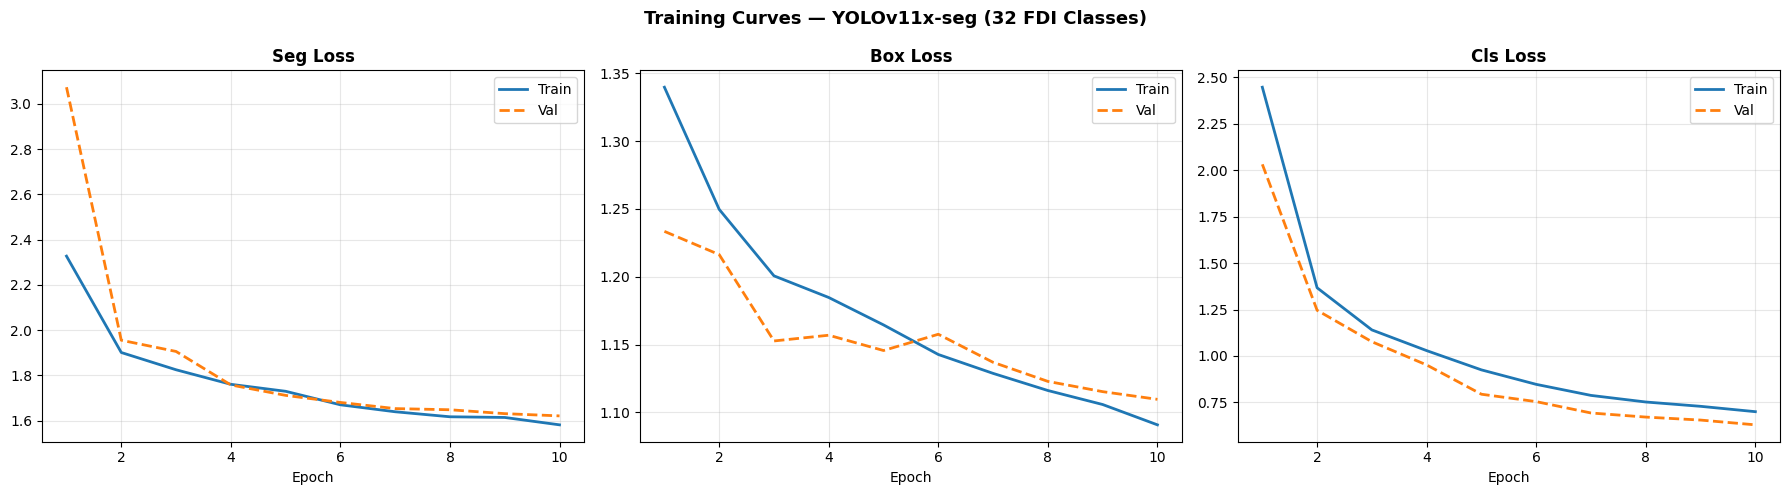

In [29]:
# ── Training curves ───────────────────────────────────────────────────────────
csv_path = Path(results.save_dir) / 'results.csv'
df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()

metrics_pairs = [
    ('train/seg_loss',      'val/seg_loss',      'Seg Loss'),
    ('train/box_loss',      'val/box_loss',       'Box Loss'),
    ('train/cls_loss',      'val/cls_loss',       'Cls Loss'),
]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (tr_col, vl_col, title) in zip(axes, metrics_pairs):
    if tr_col in df.columns:
        ax.plot(df['epoch'], df[tr_col], label='Train', linewidth=2)
    if vl_col in df.columns:
        ax.plot(df['epoch'], df[vl_col], label='Val',   linewidth=2, linestyle='--')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Training Curves — YOLOv11x-seg (32 FDI Classes)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(WORK_DIR / 'training_curves.png', dpi=130)
plt.show()


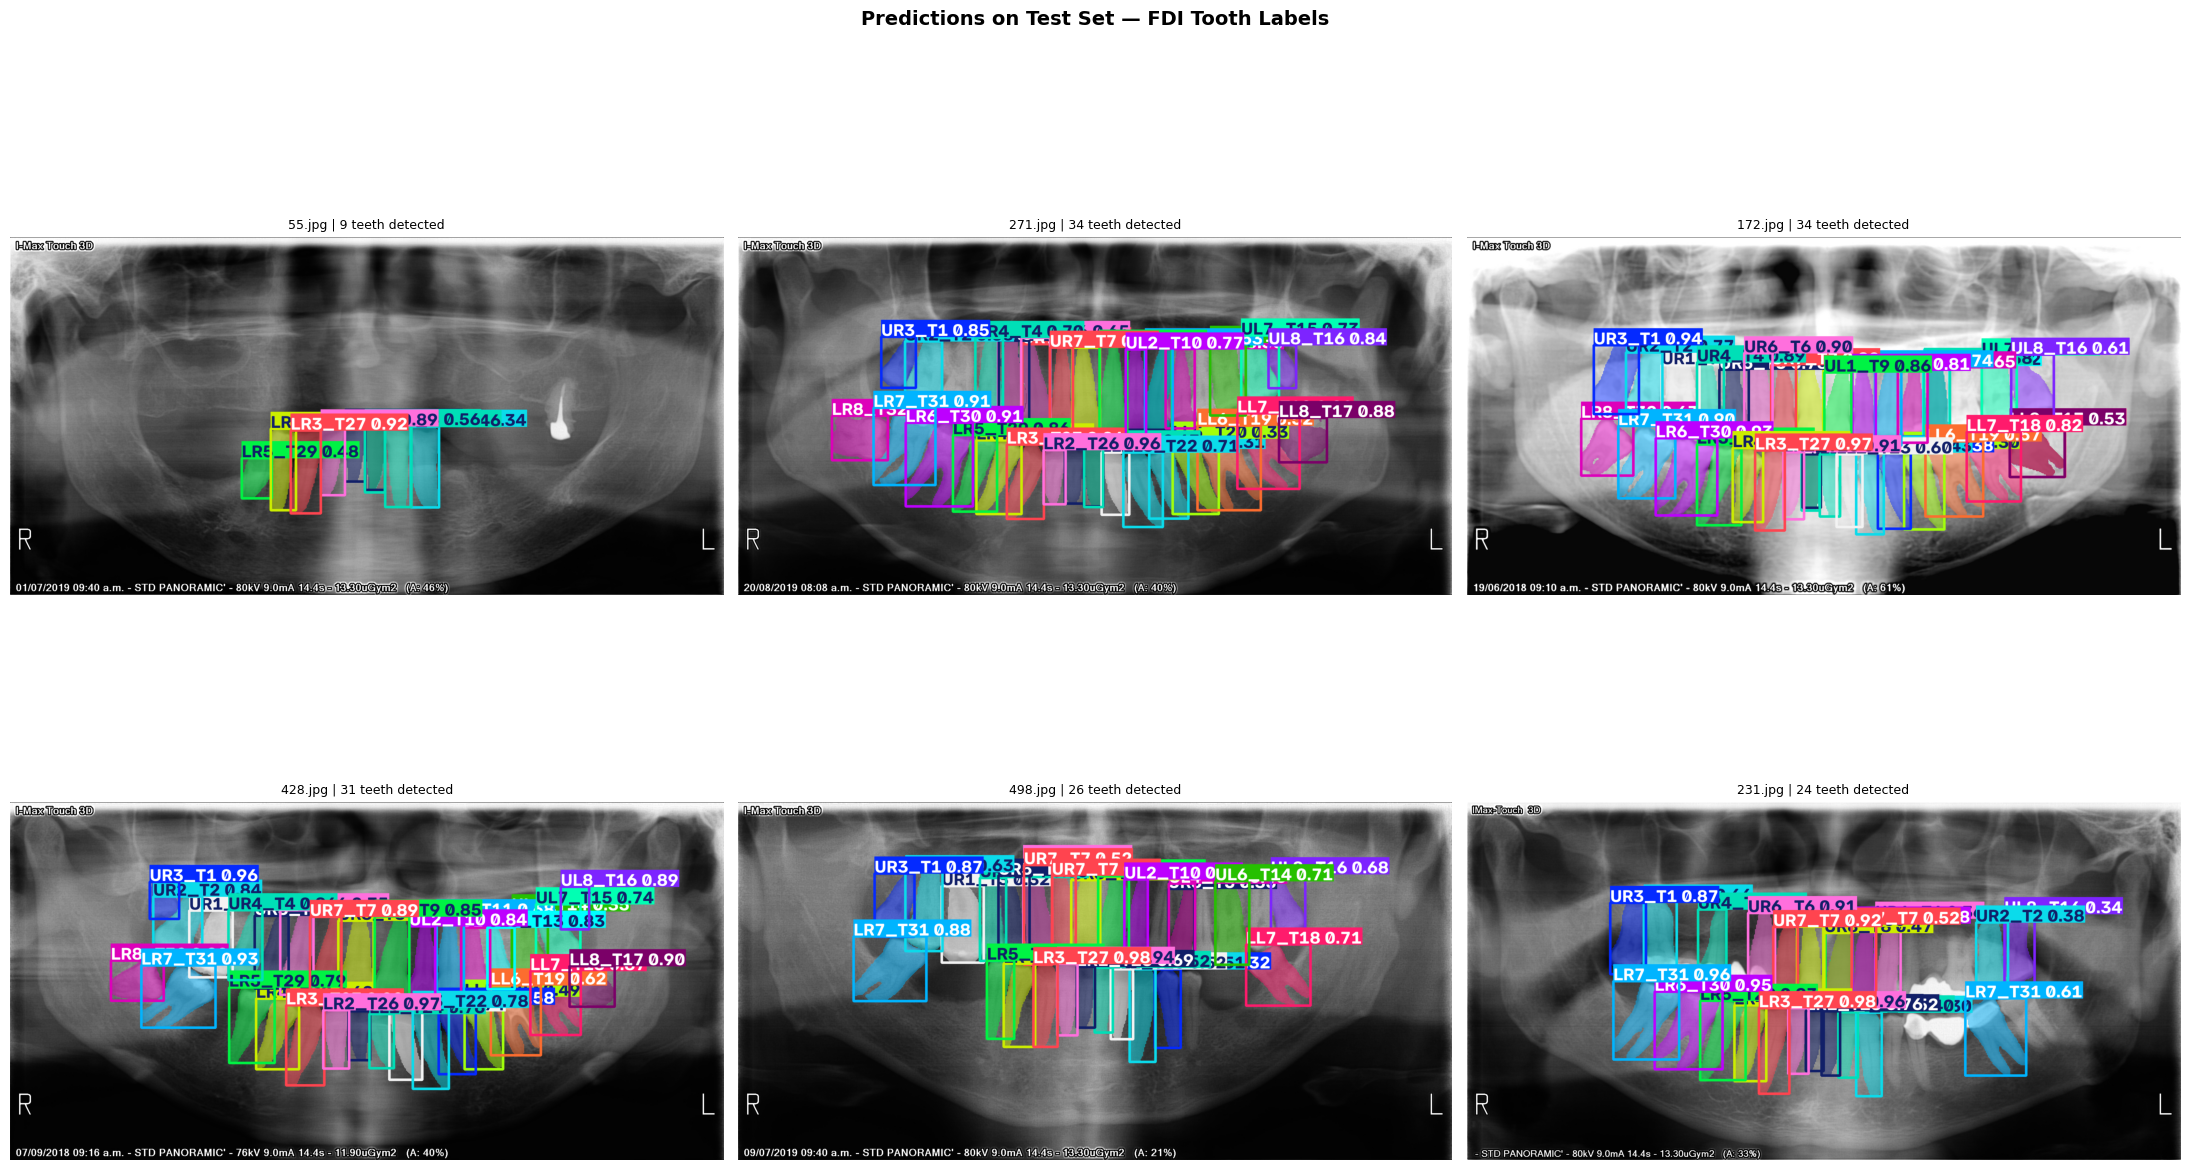

In [30]:
test_images = list((YOLO_DIR / 'images' / 'test').glob('*'))
sample_imgs = random.sample(test_images, min(6, len(test_images)))

fig, axes = plt.subplots(2, 3, figsize=(22, 14))
for ax, img_path in zip(axes.flat, sample_imgs):
    preds = best_model.predict(
        source  = str(img_path),
        imgsz   = 640,
        conf    = 0.30,
        iou     = 0.45,
        device  = '0',
        verbose = False,
    )
    annotated = preds[0].plot()
    n_detected = len(preds[0].boxes) if preds[0].boxes is not None else 0

    ax.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    ax.set_title(f'{img_path.name[:28]} | {n_detected} teeth detected', fontsize=9)
    ax.axis('off')

plt.suptitle('Predictions on Test Set — FDI Tooth Labels', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(WORK_DIR / 'test_predictions.png', dpi=130)
plt.show()

Test inference: 100%|██████████| 30/30 [00:01<00:00, 16.38it/s]


Avg teeth detected per image : 24.7
Max teeth detected in 1 image: 44


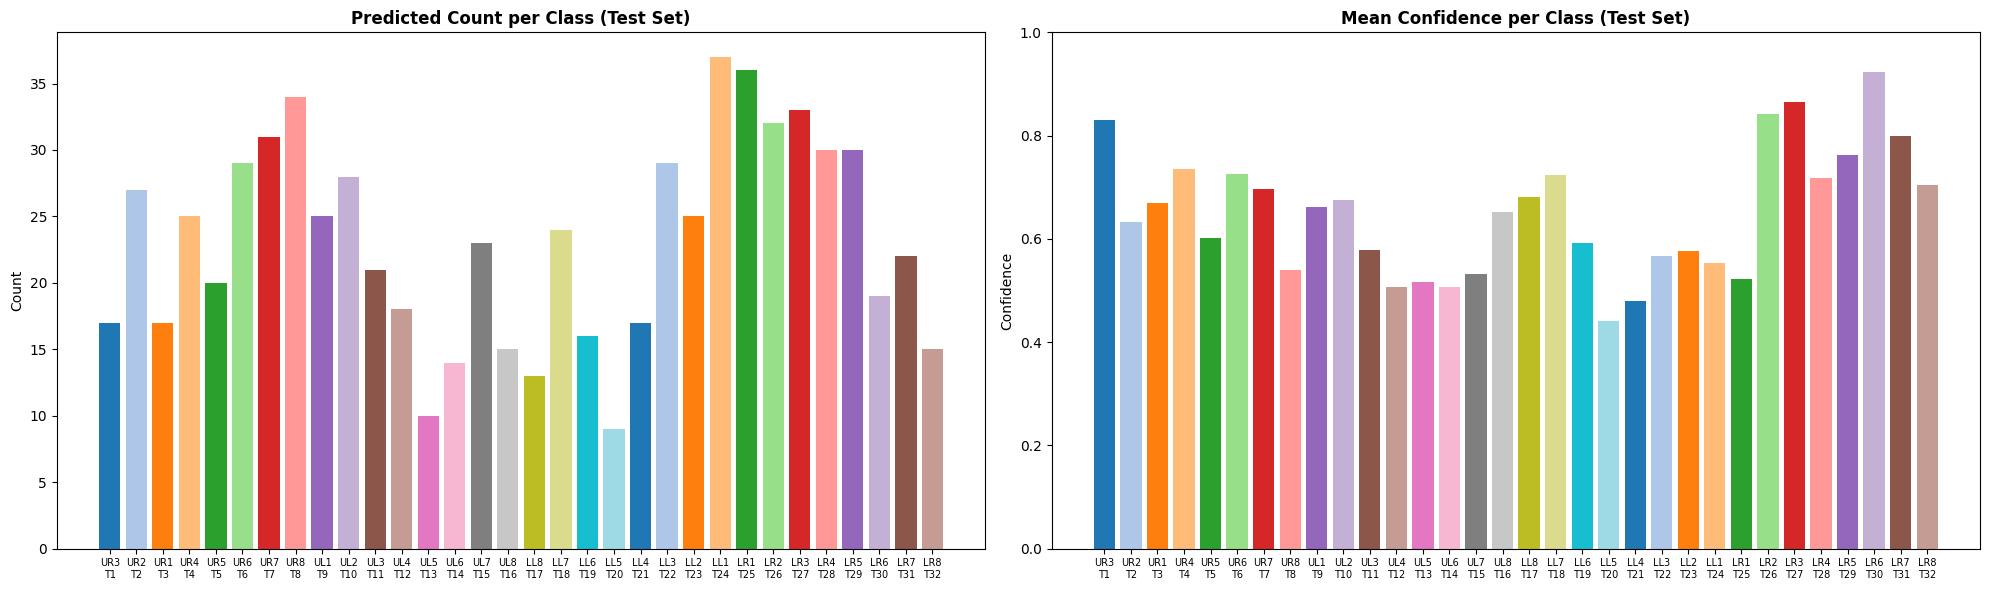

In [31]:
# ── Detailed prediction breakdown on full test set ────────────────────────────

from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

pred_counts = defaultdict(int)
pred_confs = defaultdict(list)
detections_per_image = []

for img_path in tqdm(test_images, desc='Test inference'):
    preds = best_model.predict(
        str(img_path),
        imgsz=640,
        conf=0.30,
        device=0,      # ✔ better than '0'
        verbose=False
    )

    boxes = preds[0].boxes

    if boxes is None or len(boxes) == 0:
        detections_per_image.append(0)
        continue

    n = len(boxes)
    detections_per_image.append(n)

    for cls_id, conf in zip(
        boxes.cls.cpu().numpy(),
        boxes.conf.cpu().numpy()
    ):
        cls_key = CLASSES[int(cls_id)]
        pred_counts[cls_key] += 1
        pred_confs[cls_key].append(float(conf))

print(f'Avg teeth detected per image : {np.mean(detections_per_image):.1f}')
print(f'Max teeth detected in 1 image: {max(detections_per_image)}')

# ── Colors (FIXED) ────────────────────────────────────────────────────────────
colors = plt.cm.tab20.colors  # ✔ safe, scalable palette

# ── Prepare data ─────────────────────────────────────────────────────────────
short_names = [
    FDI_NAMES[c].split(' - ')[0] + f'\nT{c}'
    for c in CLASSES
]

counts_pred = [pred_counts.get(c, 0) for c in CLASSES]
confs_pred = [
    np.mean(pred_confs[c]) if pred_confs.get(c) else 0
    for c in CLASSES
]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# Count plot
axes[0].bar(short_names, counts_pred, color=colors)
axes[0].set_title('Predicted Count per Class (Test Set)', fontweight='bold')
axes[0].set_ylabel('Count')
plt.setp(axes[0].get_xticklabels(), fontsize=7)

# Confidence plot
axes[1].bar(short_names, confs_pred, color=colors)
axes[1].set_title('Mean Confidence per Class (Test Set)', fontweight='bold')
axes[1].set_ylabel('Confidence')
axes[1].set_ylim(0, 1)
plt.setp(axes[1].get_xticklabels(), fontsize=7)

plt.tight_layout()
plt.savefig(WORK_DIR / 'class_stats_test.png', dpi=130)
plt.show()


--- Procesando imagen: 271.jpg ---
Se encontraron 34 detecciones.


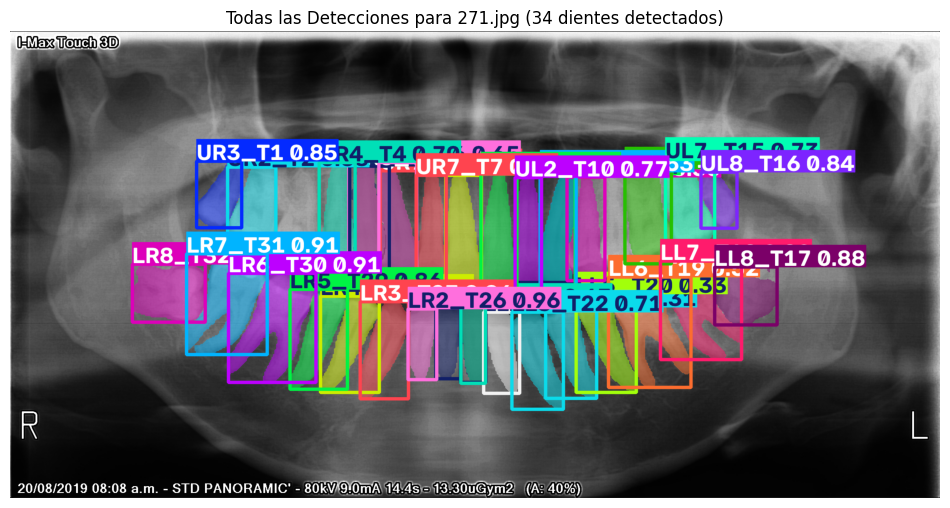

Mostrando hasta 5 detecciones individuales...


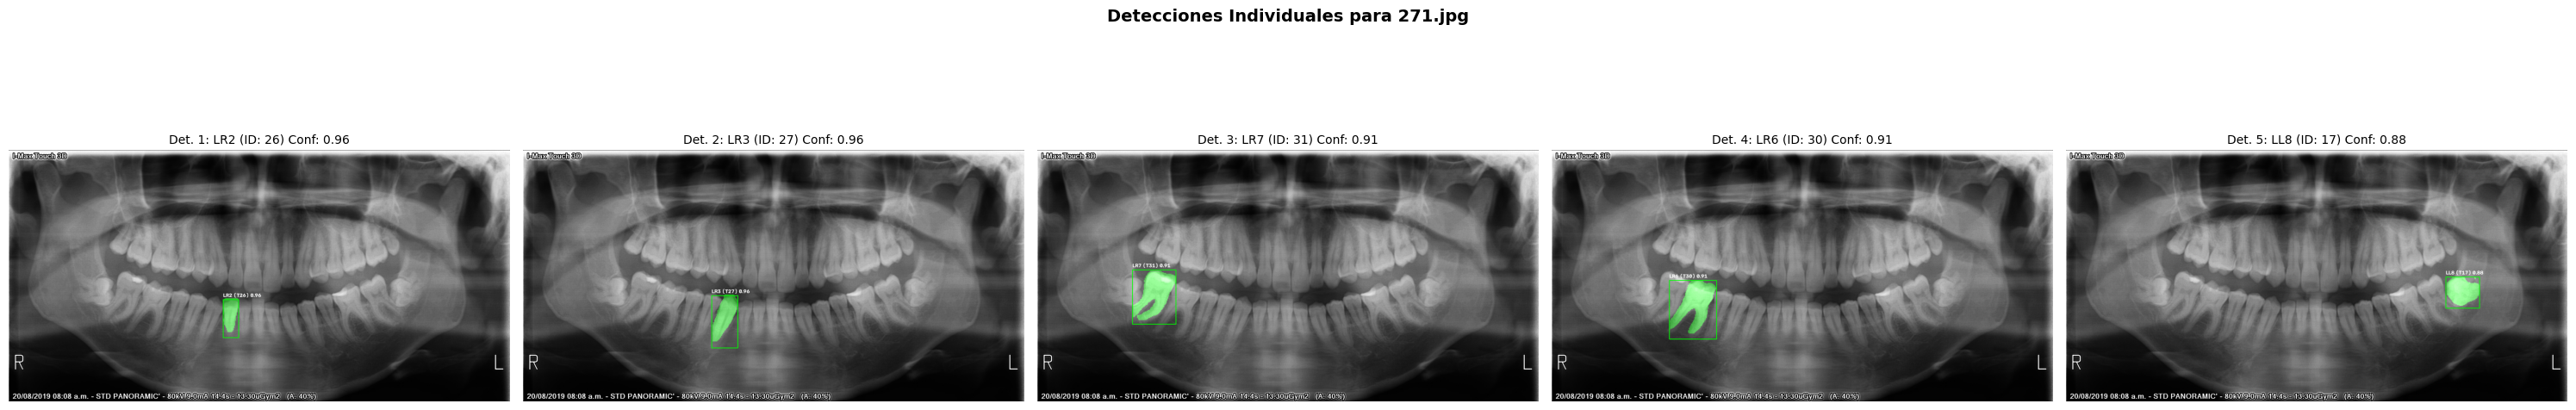


--- Procesando imagen: 172.jpg ---
Se encontraron 34 detecciones.


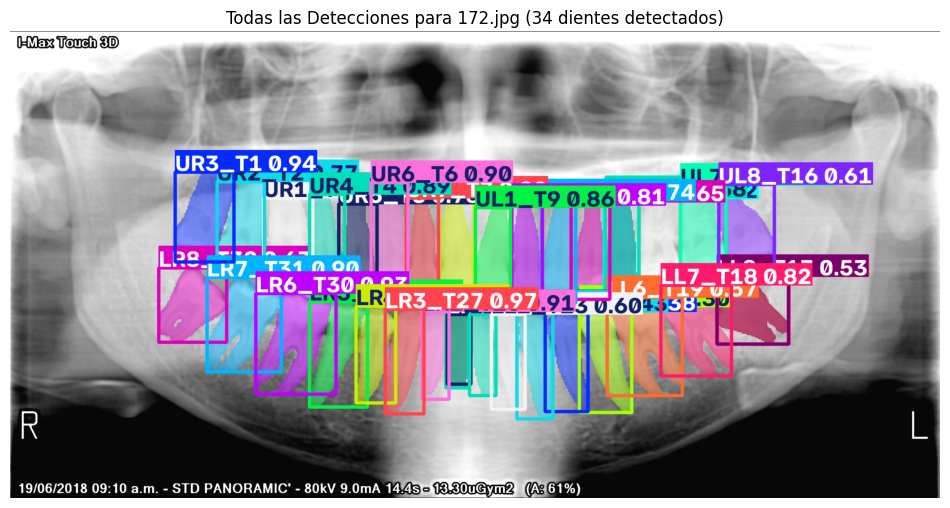

Mostrando hasta 5 detecciones individuales...


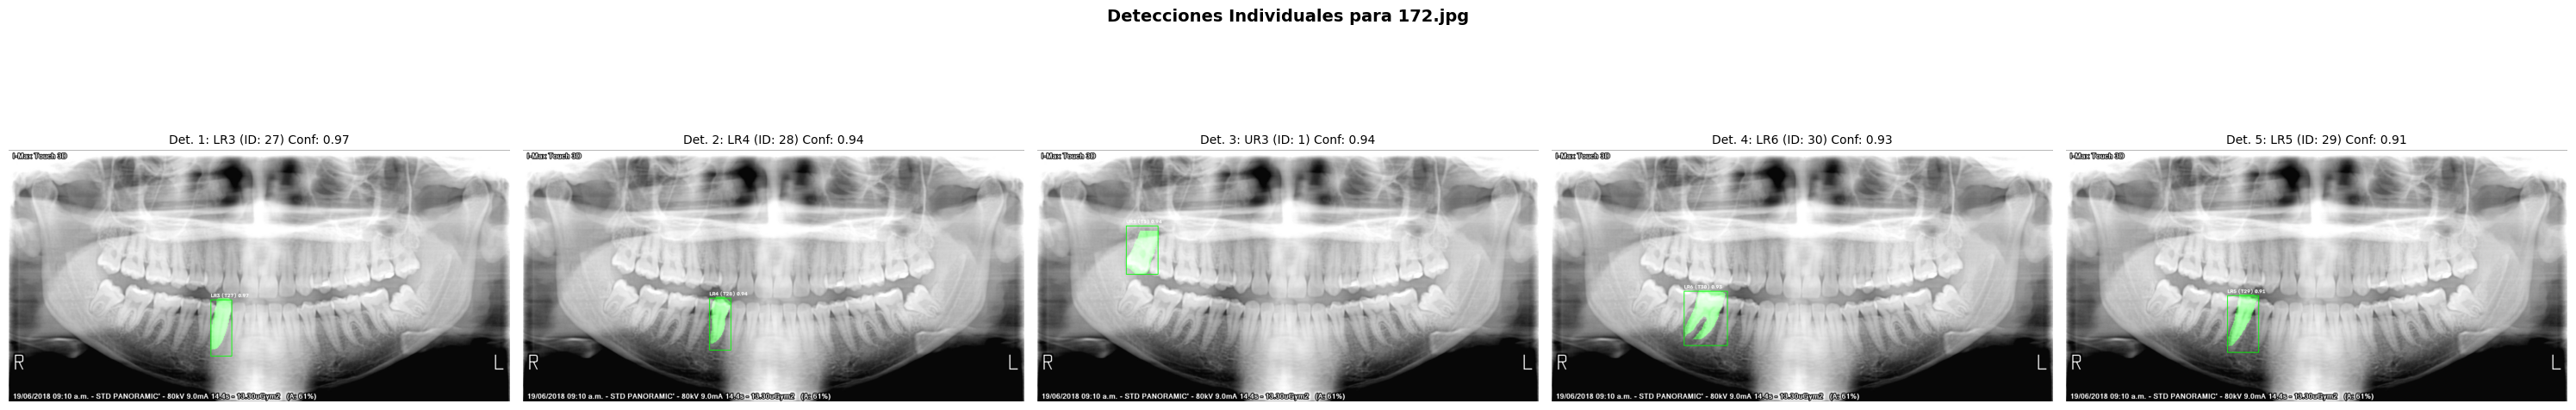


--- Procesando imagen: 231.jpg ---
Se encontraron 24 detecciones.


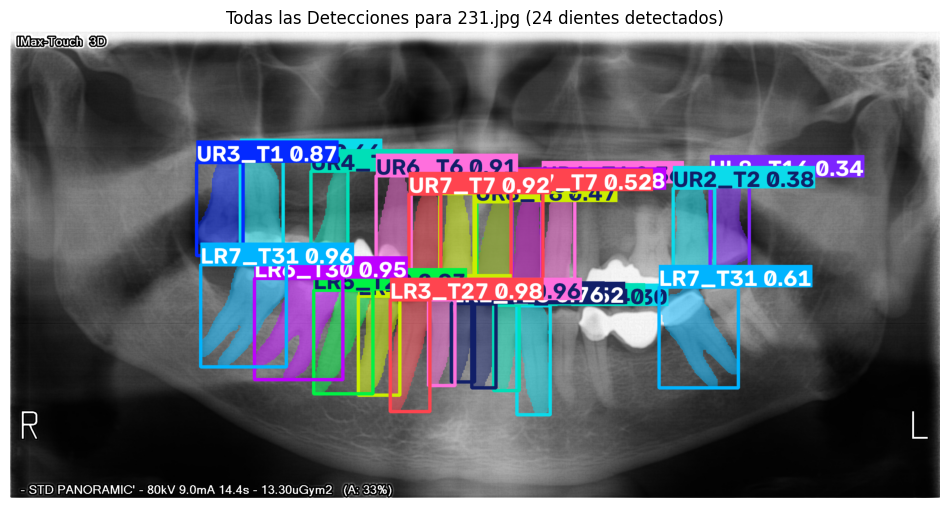

Mostrando hasta 5 detecciones individuales...


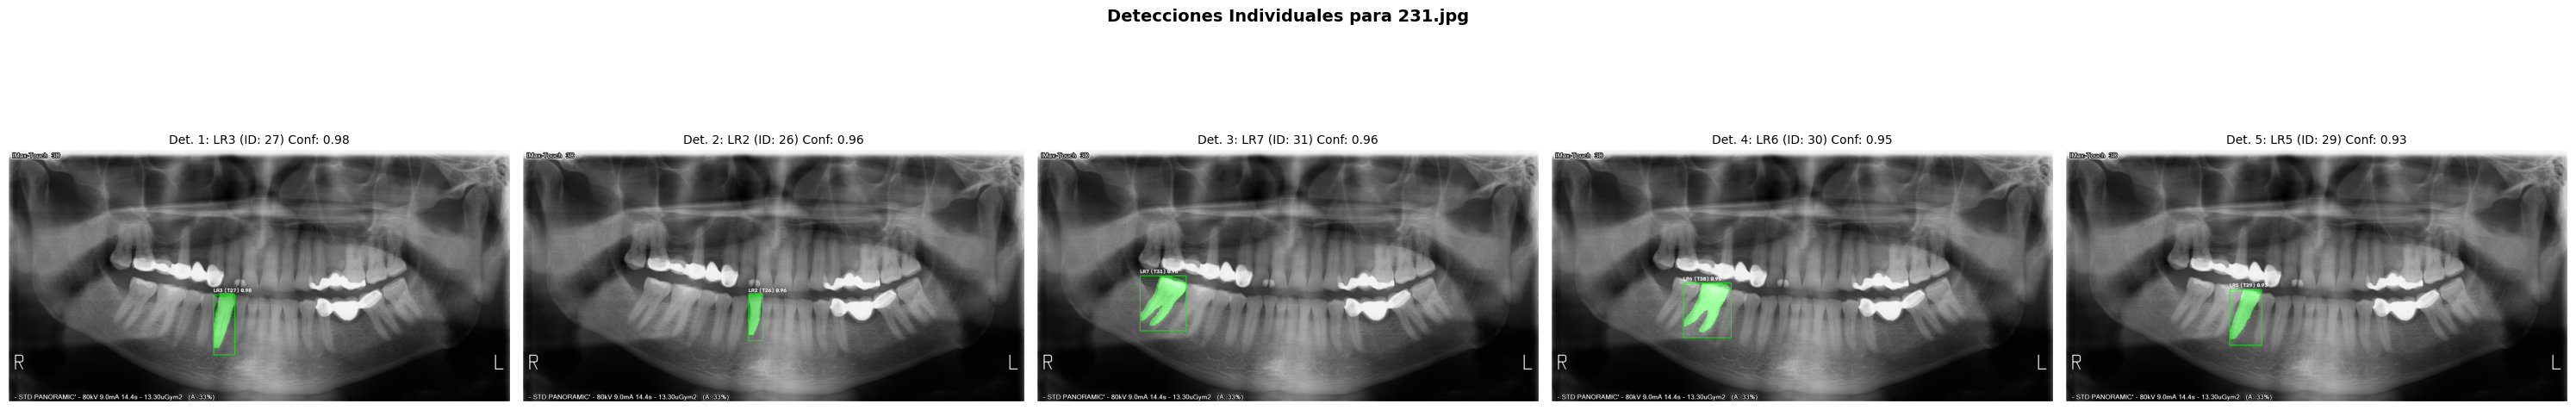


✅ Visualización de detecciones individuales completada!


In [39]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
from PIL import Image
import random

# --- Configuration ---
NUM_SAMPLE_IMAGES = 3  # Número de imágenes de prueba a visualizar
MAX_INDIVIDUAL_DETECTIONS_PER_IMAGE = 5 # Máximo de detecciones individuales a mostrar por imagen

# Seleccionar imágenes de prueba aleatorias
sample_imgs = random.sample(test_images, min(NUM_SAMPLE_IMAGES, len(test_images)))

for img_path in sample_imgs:
    print(f"\n--- Procesando imagen: {img_path.name} ---")

    # Cargar la imagen original usando PIL y luego convertir a numpy para matplotlib
    original_img_pil = Image.open(img_path).convert('RGB')
    # Cargar la imagen original con OpenCV para funciones de dibujo (OpenCV usa BGR por defecto)
    original_img_bgr = cv2.imread(str(img_path))

    # Realizar la predicción
    preds = best_model.predict(
        source  = str(img_path),
        imgsz   = 640,
        conf    = 0.30,
        iou     = 0.45,
        device  = '0',
        verbose = False,
    )

    pred = preds[0] # Obtener resultados para la imagen actual

    # Verificar si se realizaron detecciones
    if pred.boxes is None or len(pred.boxes) == 0:
        n_detecciones = 0 # Si no hay detecciones, asignar 0
        print(f"No se encontraron detecciones para {img_path.name}.")
        # Mostrar opcionalmente la imagen original
        plt.figure(figsize=(8, 8))
        plt.imshow(original_img_pil)
        plt.title(f"{img_path.name}: Sin detecciones")
        plt.axis('off')
        plt.show()
        continue # Continuar con la siguiente imagen
    else:
        # Obtener los cuadros delimitadores, máscaras, IDs de clase y confianzas
        boxes = pred.boxes.xyxy.cpu().numpy()
        masks = pred.masks.data.cpu().numpy() # Máscaras en formato numpy
        classes = pred.boxes.cls.cpu().numpy().astype(int)
        confs = pred.boxes.conf.cpu().numpy()

        n_detecciones = len(boxes) # Asignar el número real de detecciones
        print(f"Se encontraron {n_detecciones} detecciones.")

    # --- Trazar todas las detecciones en una imagen primero ---
    annotated_all = pred.plot() # Plot de Ultralytics con todas las detecciones
    plt.figure(figsize=(12, 10))
    plt.imshow(cv2.cvtColor(annotated_all, cv2.COLOR_BGR2RGB)) # Convertir de BGR a RGB para matplotlib
    plt.title(f"Todas las Detecciones para {img_path.name} ({n_detecciones} dientes detectados)")
    plt.axis('off')
    plt.show()

    # --- Ahora, trazar detecciones individuales ---
    print(f"Mostrando hasta {MAX_INDIVIDUAL_DETECTIONS_PER_IMAGE} detecciones individuales...")
    num_to_show = min(n_detecciones, MAX_INDIVIDUAL_DETECTIONS_PER_IMAGE)

    if num_to_show > 0:
        fig_individual, axes_individual = plt.subplots(1, num_to_show, figsize=(6 * num_to_show, 6))
        # Asegurarse de que axes_individual sea siempre un array, incluso para num_to_show=1
        if num_to_show == 1:
            axes_individual = [axes_individual]

        for i in range(num_to_show):
            ax = axes_individual[i]

            # Comenzar con una copia limpia de la imagen original para cada gráfico
            img_with_one_detection = original_img_bgr.copy()

            # Obtener datos de la detección actual
            mask_data = masks[i] # Máscara (booleana o float 0-1) del tamaño de la imagen del modelo
            box = boxes[i]
            cls_id = classes[i]
            conf = confs[i]

            # Obtener el nombre de la clase usando ID2NAME
            # Convertir el ID de clase (0-31) al string de diente ('1'-'32')
            original_class_str = CLASSES[cls_id]
            class_name = FDI_NAMES.get(original_class_str, f"Unknown_{original_class_str}")

            # Redimensionar mask_data para que coincida con el tamaño de la imagen original
            h, w, _ = img_with_one_detection.shape
            resized_mask_data = cv2.resize(mask_data, (w, h), interpolation=cv2.INTER_NEAREST)

            # Crear una máscara de color de 3 canales
            color_mask = np.zeros_like(img_with_one_detection, dtype=np.uint8)
            mask_color = (0, 255, 0) # Color verde para la visualización (BGR)
            alpha = 0.4 # Transparencia

            # Aplicar la máscara de color
            # Para cada canal, aplicar la máscara usando la máscara redimensionada
            for c in range(3):
                color_mask[:, :, c] = resized_mask_data * mask_color[c]

            # Fusionar la máscara con la imagen
            img_with_one_detection = cv2.addWeighted(img_with_one_detection, 1, color_mask, alpha, 0)

            # Dibujar el cuadro delimitador
            x1, y1, x2, y2 = map(int, box)
            cv2.rectangle(img_with_one_detection, (x1, y1), (x2, y2), mask_color, 2)

            # Añadir texto (nombre de clase y confianza)
            label = f"{class_name.split(' - ')[0]} (T{original_class_str}) {conf:.2f}"
            cv2.putText(img_with_one_detection, label, (x1, y1 - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2, cv2.LINE_AA) # Texto blanco

            ax.imshow(cv2.cvtColor(img_with_one_detection, cv2.COLOR_BGR2RGB))
            ax.set_title(f"Det. {i+1}: {class_name.split(' - ')[0]} (ID: {original_class_str}) Conf: {conf:.2f}", fontsize=10)
            ax.axis('off')

        plt.suptitle(f"Detecciones Individuales para {img_path.name}", fontsize=14, fontweight='bold')
        plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajustar diseño para hacer espacio para el título principal
        plt.show()

print("\n✅ Visualización de detecciones individuales completada!")